In [ ]:
import pandas as pd
tracks = pd.read_csv("fma-rock-vs-hiphop.csv")
echonest_metrics = pd.read_json("echonest-metrics.json", precise_float=True)
echo_tracks = pd.merge(echonest_metrics, tracks[["track_id", "genre_top"]], on="track_id")
echo_tracks.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4802 entries, 0 to 4801
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          4802 non-null   int64  
 1   acousticness      4802 non-null   float64
 2   danceability      4802 non-null   float64
 3   energy            4802 non-null   float64
 4   instrumentalness  4802 non-null   float64
 5   liveness          4802 non-null   float64
 6   speechiness       4802 non-null   float64
 7   tempo             4802 non-null   float64
 8   valence           4802 non-null   float64
 9   genre_top         4802 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 412.7+ KB


In [ ]:
corr_metrics = echo_tracks.corr()
corr_metrics.style.background_gradient()


<ipython-input-2-d48f28433f94>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_metrics = echo_tracks.corr()


,track_id,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence
track_id,1.000000,-0.372282,0.049454,0.140703,-0.275623,0.048231,-0.026995,-0.025392,0.010070
acousticness,-0.372282,1.000000,-0.028954,-0.281619,0.194780,-0.019991,0.072204,-0.026310,-0.013841
danceability,0.049454,-0.028954,1.000000,-0.242032,-0.255217,-0.106584,0.276206,-0.242089,0.473165
energy,0.140703,-0.281619,-0.242032,1.000000,0.028238,0.113331,-0.109983,0.195227,0.038603
instrumentalness,-0.275623,0.194780,-0.255217,0.028238,1.000000,-0.091022,-0.366762,0.022215,-0.219967
liveness,0.048231,-0.019991,-0.106584,0.113331,-0.091022,1.000000,0.041173,0.002732,-0.045093
speechiness,-0.026995,0.072204,0.276206,-0.109983,-0.366762,0.041173,1.000000,0.008241,0.149894
tempo,-0.025392,-0.026310,-0.242089,0.195227,0.022215,0.002732,0.008241,1.000000,0.052221
valence,0.010070,-0.013841,0.473165,0.038603,-0.219967,-0.045093,0.149894,0.052221,1.000000


<ipython-input-3-6add515987c6>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = tracks.corr()


<Axes: >

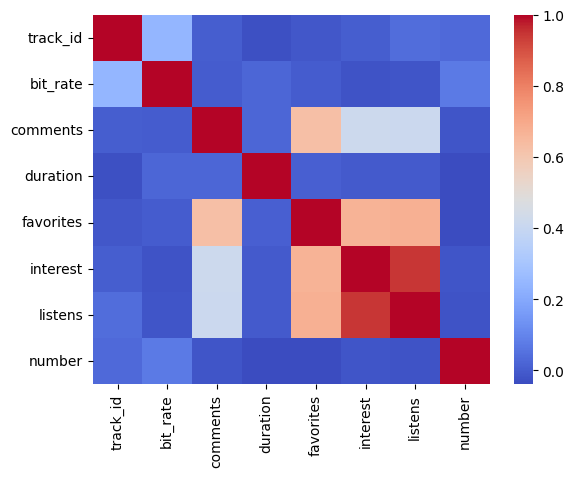

In [ ]:
import seaborn as sns
corr_matrix = tracks.corr()
sns.heatmap(corr_matrix, cmap='coolwarm')

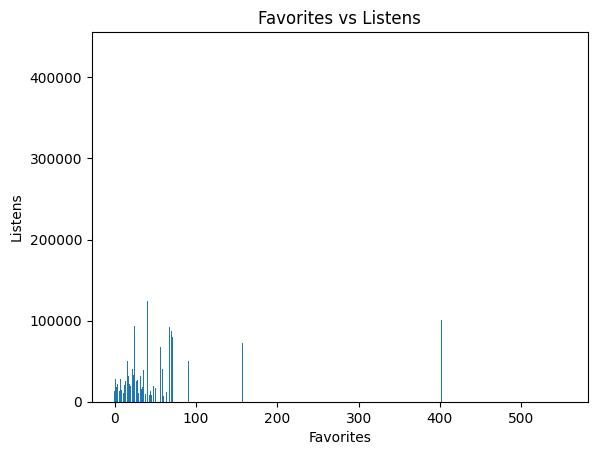

In [ ]:
from matplotlib import pyplot as plt
favorites = tracks['favorites']
listens=tracks['listens']
plt.bar(favorites, listens)
plt.xlabel('Favorites')
plt.ylabel('Listens')
plt.title('Favorites vs Listens')
# Show the plot
plt.show()


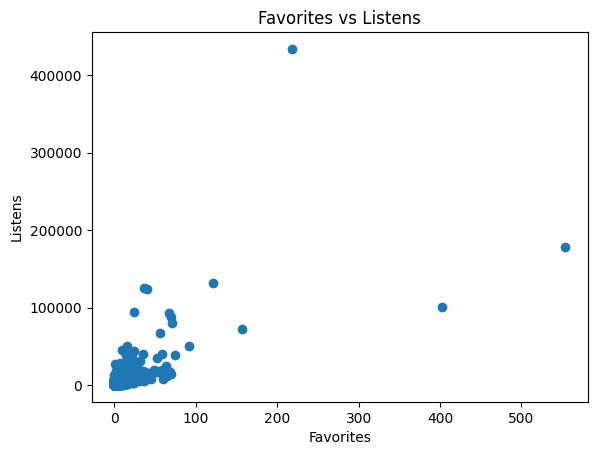

In [ ]:
from matplotlib import pyplot as plt

favorites = tracks['favorites']
listens = tracks['listens']
plt.scatter(favorites, listens)
plt.xlabel('Favorites')
plt.ylabel('Listens')
plt.title('Favorites vs Listens')
plt.show()

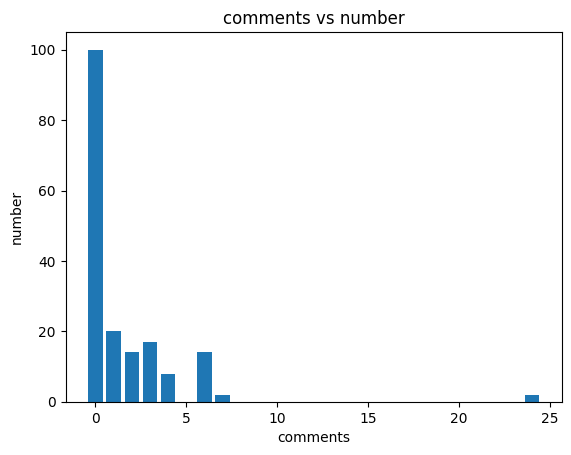

In [ ]:
comments=tracks['comments']
number = tracks['number']
plt.bar(comments,number)
plt.xlabel('comments')
plt.ylabel('number')
plt.title('comments vs number')
plt.show()

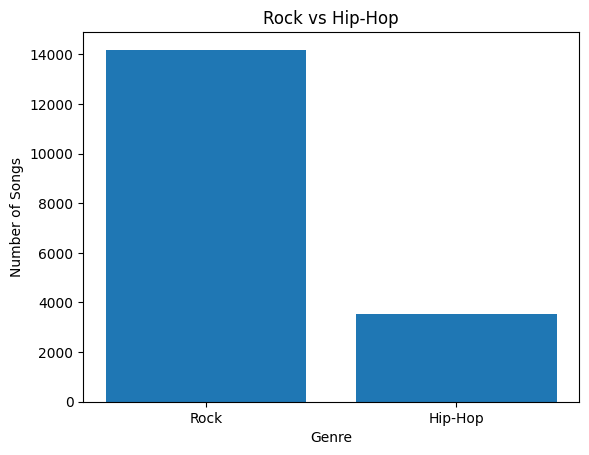

In [ ]:
counts = tracks['genre_top'].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel('Genre')
plt.ylabel('Number of Songs')
plt.title('Rock vs Hip-Hop')
plt.show()

### **Finding Mean Values**

In [ ]:
rock_tracks = tracks[tracks['genre_top'] == 'Rock']
hiphop_tracks = tracks[tracks['genre_top'] == 'Hip-Hop']
rock_means = rock_tracks.mean()
hiphop_means = hiphop_tracks.mean()
table = pd.concat([rock_means, hiphop_means], axis=1)
table.columns = ['Rock', 'Hip-Hop']
print(table)

                    Rock        Hip-Hop
track_id    67062.675011   78702.963964
bit_rate   253943.741362  279045.301802
comments        0.016782       0.036318
duration      225.497109     202.759572
favorites       1.443449       2.650619
interest     1433.407418    2655.770552
listens       931.371104    1671.977477
number          5.764843       7.858108


<ipython-input-8-eaaa72dc47ce>:3: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  rock_means = rock_tracks.mean()
<ipython-input-8-eaaa72dc47ce>:4: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  hiphop_means = hiphop_tracks.mean()


In [ ]:
features = echo_tracks.drop(["genre_top","track_id"], axis=1)
labels = echo_tracks["genre_top"]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_train_features = scaler.fit_transform(features)

[0.24297674 0.18044316 0.13650309 0.12994089 0.11056248 0.08302245
 0.06923783 0.04731336]
8


Text(0.5, 0, 'Principal Component')

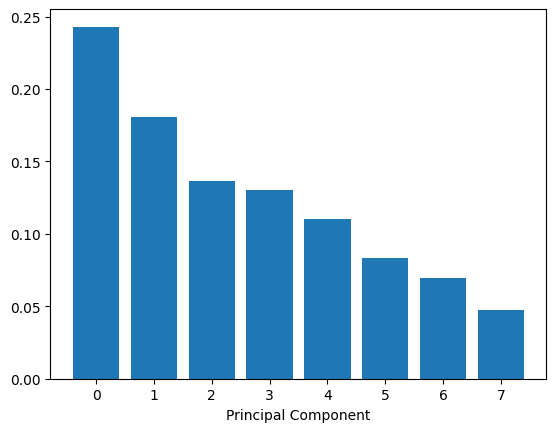

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(scaled_train_features)
exp_variance = pca.explained_variance_ratio_

print(pca.explained_variance_ratio_)
print(pca.n_components_)
fig, ax = plt.subplots()
ax.bar(range(8), exp_variance)
ax.set_xlabel('Principal Component')

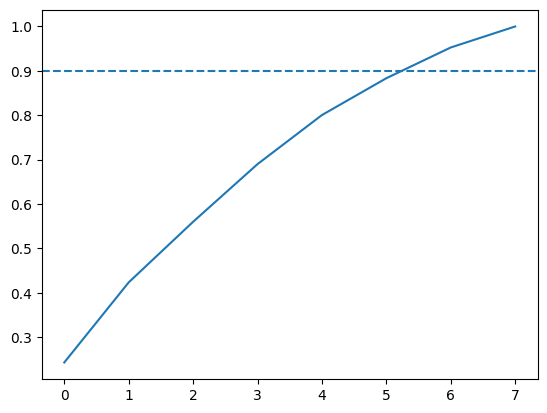

In [ ]:
import numpy as np
cum_exp_variance = np.cumsum(exp_variance)
fig, ax = plt.subplots()
ax.plot(range(8), cum_exp_variance)
ax.axhline(y=0.9, linestyle='--')
n_components = 6
pca = PCA(n_components, random_state=10)
pca.fit(scaled_train_features)
pca_projection = pca.transform(scaled_train_features)

In [ ]:

from sklearn.model_selection import train_test_split
train_features, test_features, train_labels, test_labels = train_test_split(pca_projection, labels, random_state=10)


In [ ]:
hop_only = echo_tracks.loc[echo_tracks["genre_top"] == "Hip-Hop"]
rock_only = echo_tracks.loc[echo_tracks["genre_top"] == "Rock"].sample(len(hop_only), random_state=10)
rock_hop_bal = pd.concat([rock_only, hop_only])
features = rock_hop_bal.drop(['genre_top', 'track_id'], axis=1)
labels = rock_hop_bal['genre_top']
pca_projection = pca.fit_transform(scaler.fit_transform(features))
train_features, test_features, train_labels, test_labels = train_test_split(pca_projection, labels, random_state=10)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

tree = DecisionTreeClassifier(random_state=10)
tree.fit(train_features, train_labels)
pred_labels_tree = tree.predict(test_features)

logreg = LogisticRegression(random_state=10)
logreg.fit(train_features, train_labels)
pred_labels_logit = logreg.predict(test_features)

neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(train_features, train_labels)
pred_labels_neigh = neigh.predict(test_features)

forest=RandomForestClassifier(n_estimators=100)
forest.fit(train_features, train_labels)
pred_labels_forest = forest.predict(test_features)


suport=SVC(gamma='auto')
suport.fit(train_features, train_labels)
pred_labels_suport = suport.predict(test_features)


print("Decision Tree: \n", classification_report(test_labels, pred_labels_tree))
print("Logistic Regression: \n", classification_report(test_labels, pred_labels_logit))
print("knn: \n", classification_report(test_labels, pred_labels_neigh))
print("Random Forest: \n", classification_report(test_labels, pred_labels_forest))
print("Suport Vector: \n", classification_report(test_labels, pred_labels_suport))

Decision Tree: 
               precision    recall  f1-score   support

     Hip-Hop       0.74      0.73      0.74       230
        Rock       0.73      0.74      0.73       225

    accuracy                           0.74       455
   macro avg       0.74      0.74      0.74       455
weighted avg       0.74      0.74      0.74       455

Logistic Regression: 
               precision    recall  f1-score   support

     Hip-Hop       0.84      0.80      0.82       230
        Rock       0.80      0.85      0.83       225

    accuracy                           0.82       455
   macro avg       0.82      0.82      0.82       455
weighted avg       0.82      0.82      0.82       455

knn: 
               precision    recall  f1-score   support

     Hip-Hop       0.87      0.83      0.85       230
        Rock       0.83      0.88      0.85       225

    accuracy                           0.85       455
   macro avg       0.85      0.85      0.85       455
weighted avg       0.85    

In [ ]:
from sklearn.metrics import confusion_matrix

# Decision Tree
cm_tree = confusion_matrix(test_labels, pred_labels_tree)
print(" Decision Tree:")
print(cm_tree)

# Logistic Regression
cm_logit = confusion_matrix(test_labels, pred_labels_logit)
print("Logistic Regression:")
print(cm_logit)

# KNN
cm_neigh = confusion_matrix(test_labels, pred_labels_neigh)
print("KNN:")
print(cm_neigh)

# Random Forest
cm_forest = confusion_matrix(test_labels, pred_labels_forest)
print(" Random Forest:")
print(cm_forest)

# Support Vector Machine
cm_suport = confusion_matrix(test_labels, pred_labels_suport)
print("Support Vector :")
print(cm_suport)


 Decision Tree:
[[169  61]
 [ 59 166]]
Logistic Regression:
[[183  47]
 [ 34 191]]
KNN:
[[190  40]
 [ 28 197]]
 Random Forest:
[[188  42]
 [ 29 196]]
Support Vector :
[[190  40]
 [ 28 197]]


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define a function to plot confusion matrix
def plot_confusion_matrix(model, test_features, test_labels):

  predictions = model.predict(test_features)
  cm = confusion_matrix(test_labels, predictions)
  sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.show()
  plot_confusion_matrix(logreg, test_features, test_labels)
  plot_confusion_matrix(tree, test_features, test_labels)
  plot_confusion_matrix(suport, test_features, test_labels)
  plot_confusion_matrix(forest, test_features, test_labels)
  plot_confusion_matrix(neigh, test_features, test_labels)

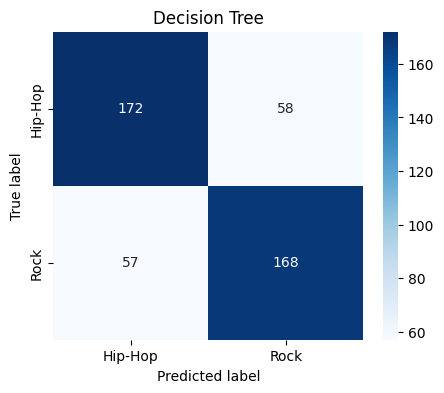

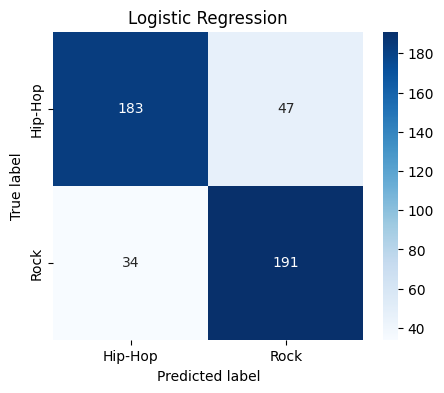

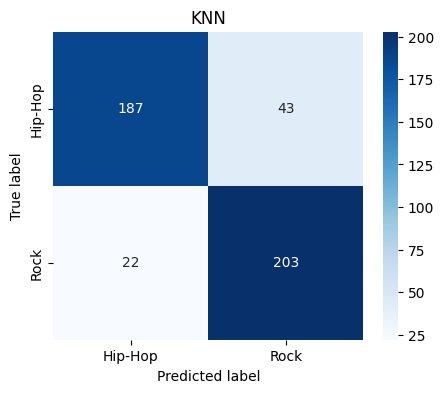

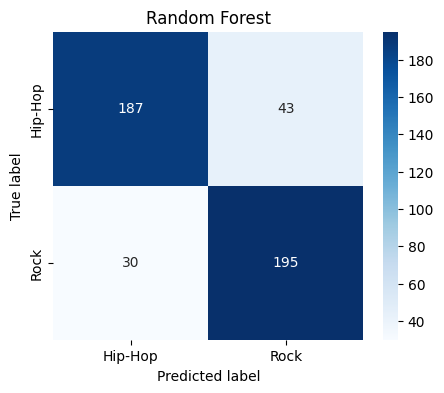

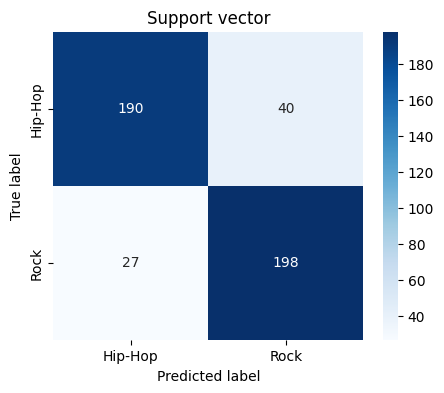

In [ ]:
from sklearn.metrics import confusion_matrix
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Support vector': SVC()
}

for name, model in models.items():
    model.fit(train_features, train_labels)
    y_pred = model.predict(test_features)

    # Create confusion matrix
    cm = confusion_matrix(test_labels, y_pred)

    # Create heatmap visualization of confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=["Hip-Hop", "Rock"], yticklabels=["Hip-Hop", "Rock"])
    plt.title(name)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()


In [ ]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=10, random_state=None, shuffle=False)

tree = DecisionTreeClassifier(random_state=None)
logreg = LogisticRegression(random_state=None)
neigh = KNeighborsClassifier(n_neighbors=3)
forest = RandomForestClassifier(n_estimators=100)
suport=SVC(gamma='auto')

tree_score = cross_val_score(tree, pca_projection, labels, cv=kf)
logit_score = cross_val_score(logreg, pca_projection, labels, cv=kf)
neigh_score = cross_val_score(neigh, pca_projection, labels, cv=kf)
forest_score = cross_val_score(forest, pca_projection, labels, cv=kf)
suport_score = cross_val_score(suport, pca_projection, labels, cv=kf)

# Print the mean of each array of scores
print("Decision Tree:", np.mean(tree_score), "Logistic Regression:", np.mean(logit_score), "KNN:", np.mean(neigh_score), "random  forest:", np.mean(forest_score), "suport vector:", np.mean(suport_score))

Decision Tree: 0.75 Logistic Regression: 0.782967032967033 KNN: 0.8131868131868132 random  forest: 0.8197802197802198 suport vector: 0.8197802197802199


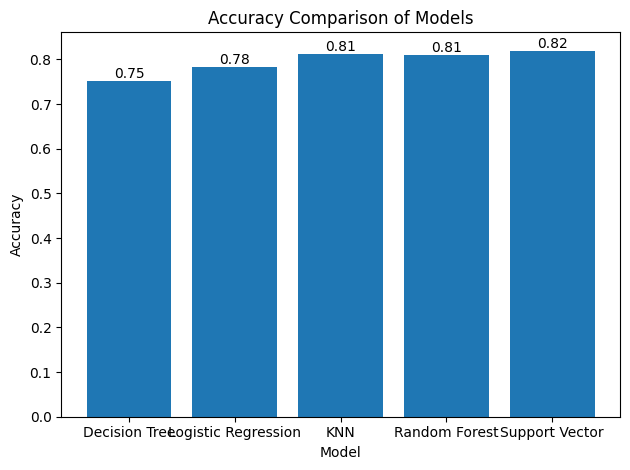

In [ ]:

models = ['Decision Tree', 'Logistic Regression', 'KNN', 'Random Forest', 'Support Vector']
accuracies = [0.752, 0.782, 0.813, 0.809, 0.8197]

fig, ax = plt.subplots()
bars = ax.bar(models, accuracies)

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison of Models')


for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), ha='center', va='bottom')


plt.tight_layout()
plt.show()
